In [1]:
import sys
import numpy as np 

# Ajouter un chemin spécifique à sys.path
new_path = '/home/tpicard/DIIO/analysis_StaM/CODE/'
sys.path.append(new_path)
from toolbox import *
import xarray as xr 
# Import 
# modules
import copernicusmarine
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from scipy.stats import pearsonr
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

import glob 
import os 

/home/tpicard/miniforge3/envs/imt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
year_start = 2010   
year_stop = 2019 #2025
depth_surf = 1
# Select time range 
date = datetime(year_start,1,1)
date_end = datetime(year_stop,12,31)

In [3]:
hfr = get_hfr(date,date_end=date_end)

get hfr ...


In [15]:
glider_L80 = get_glider_L80(year_start,year_stop)
glider_L66 = get_glider_L66(year_start,year_stop)

glider_L80 = glider_L80.where(~np.isnan(glider_L80.u), drop=True)
glider_L66 = glider_L66.where(~np.isnan(glider_L66.u), drop=True)

In [40]:
glider_L66

<xarray.Dataset> Size: 24kB
Dimensions:  (time: 603)
Coordinates:
  * time     (time) datetime64[ns] 5kB 2010-10-11 2011-05-04 ... 2019-05-29
    depth    int64 8B 15
Data variables:
    lat      (time) float64 5kB 36.02 36.82 36.78 36.76 ... 35.41 35.46 35.51
    lon      (time) float64 5kB -123.5 -122.2 -121.9 ... -125.0 -124.9 -124.8
    u        (time) float64 5kB 0.1096 -0.137 0.08923 ... -0.1761 -0.2204
    v        (time) float64 5kB -0.01244 -0.1828 0.07129 ... -0.2608 -0.3011
Attributes: (12/53)
    id:                              CUGN_line_66
    date_created:                    2026-05-04T08:40:33Z
    time_coverage_start:             2007-04-19T16:13:18Z
    time_coverage_end:               2025-11-13T21:28:00Z
    geospatial_bounds_crs:           EPSG:4326
    geospatial_bounds:               POLYGON ((-125.82682 34.304525, -125.937...
    ...                              ...
    platform_institution:            Scripps Institution of Oceanography
    sea_name:                        Coastal Waters of California
    summary:                         The overarching goal of the California U...
    references:                      Rudnick, D. L. (2016). Ocean research en...
    title:                           California Underwater Glider Network - L...
    site:                            CUGN Line 66

In [39]:
glider_L80

<xarray.Dataset> Size: 43kB
Dimensions:  (time: 1073)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2010-11-10 2011-12-10 ... 2019-05-29
    depth    int64 8B 15
Data variables:
    lat      (time) float64 9kB 33.98 34.42 34.39 33.64 ... 32.86 32.96 33.06
    lon      (time) float64 9kB -121.5 -120.6 -120.7 ... -123.8 -123.6 -123.4
    u        (time) float64 9kB -0.1905 -0.07935 -0.002431 ... -0.07895 -0.06259
    v        (time) float64 9kB -0.162 -0.01836 -0.6151 ... 0.04115 0.1076
Attributes: (12/53)
    id:                              CUGN_line_80
    date_created:                    2026-05-04T08:41:17Z
    time_coverage_start:             2005-10-13T19:06:24Z
    time_coverage_end:               2026-03-03T15:45:01Z
    geospatial_bounds_crs:           EPSG:4326
    geospatial_bounds:               POLYGON ((-123.146645 32.424454999999995...
    ...                              ...
    platform_institution:            Scripps Institution of Oceanography
    sea_name:                        Coastal Waters of California
    summary:                         The overarching goal of the California U...
    references:                      Rudnick, D. L. (2016). Ocean research en...
    title:                           California Underwater Glider Network - L...
    site:                            CUGN Line 80

In [16]:

list_lat = np.concatenate([glider_L80.lat.values, glider_L66.lat.values])
list_lon = np.concatenate([glider_L80.lon.values, glider_L66.lon.values])

In [18]:
list_lon.shape

(1676,)

In [57]:
import numpy as np
import matplotlib.pyplot as plt

zoom = [-126, -119, 32, 38.0]

lon_bins = np.linspace(zoom[0],zoom[1],71) 
lat_bins = np.linspace(zoom[2],zoom[3],61) 

# Calculer l'histogramme 2D
counts, lon_edges, lat_edges = np.histogram2d(np.array(list_lon), np.array(list_lat), bins=[lon_bins, lat_bins])
# Calculate bin centers for lon and lat
lon = 0.5 * (lon_edges[1:] + lon_edges[:-1])
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])
counts = counts.T

In [58]:
lon_bins

array([-126. , -125.9, -125.8, -125.7, -125.6, -125.5, -125.4, -125.3,
       -125.2, -125.1, -125. , -124.9, -124.8, -124.7, -124.6, -124.5,
       -124.4, -124.3, -124.2, -124.1, -124. , -123.9, -123.8, -123.7,
       -123.6, -123.5, -123.4, -123.3, -123.2, -123.1, -123. , -122.9,
       -122.8, -122.7, -122.6, -122.5, -122.4, -122.3, -122.2, -122.1,
       -122. , -121.9, -121.8, -121.7, -121.6, -121.5, -121.4, -121.3,
       -121.2, -121.1, -121. , -120.9, -120.8, -120.7, -120.6, -120.5,
       -120.4, -120.3, -120.2, -120.1, -120. , -119.9, -119.8, -119.7,
       -119.6, -119.5, -119.4, -119.3, -119.2, -119.1, -119. ])

In [59]:
lon_bins

array([-126. , -125.9, -125.8, -125.7, -125.6, -125.5, -125.4, -125.3,
       -125.2, -125.1, -125. , -124.9, -124.8, -124.7, -124.6, -124.5,
       -124.4, -124.3, -124.2, -124.1, -124. , -123.9, -123.8, -123.7,
       -123.6, -123.5, -123.4, -123.3, -123.2, -123.1, -123. , -122.9,
       -122.8, -122.7, -122.6, -122.5, -122.4, -122.3, -122.2, -122.1,
       -122. , -121.9, -121.8, -121.7, -121.6, -121.5, -121.4, -121.3,
       -121.2, -121.1, -121. , -120.9, -120.8, -120.7, -120.6, -120.5,
       -120.4, -120.3, -120.2, -120.1, -120. , -119.9, -119.8, -119.7,
       -119.6, -119.5, -119.4, -119.3, -119.2, -119.1, -119. ])

In [60]:
dist_grid = get_distance_coast(hfr.lon,hfr.lat,res='110m')

Computing distance coast grid ...


<Figure size 1500x800 with 0 Axes>

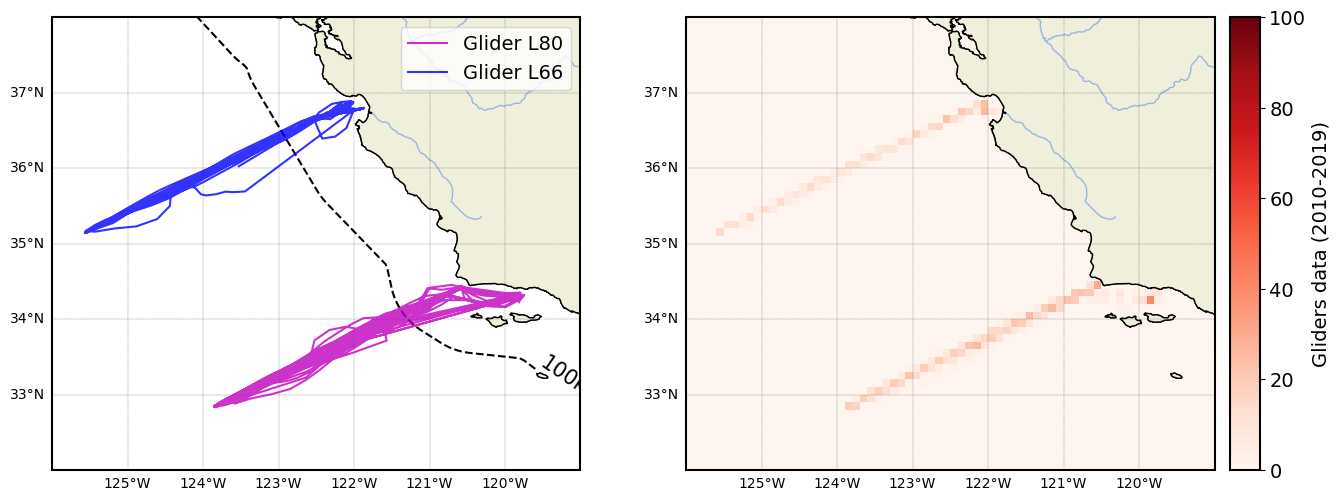

In [61]:
fig = plt.figure(figsize=(15, 8))

fig, axss = set_map(zoom=zoom,figsize=(15*1,8*1),nrows=1,ncols=2,fsize=10)

axs = axss[1]

pm = plt.pcolormesh(lon,lat,counts,cmap=plt.cm.Reds,vmax=100)
#plot_cm(counts,lon,lat,cmap=plt.cm.Reds,axs=axs,fig=fig,colorbar=True,zoom=zoom,vmax=100,colorbar_title=f'Gliders data ({year_start}-{year_stop})')
#get size and extent of axes:
axpos = axs.get_position()
pos_x = axpos.x0+axpos.width + 0.01# + 0.25*axpos.width
pos_y = axpos.y0
cax_width = 0.02
cax_height = axpos.height

pos_cax = fig.add_axes([pos_x,pos_y,cax_width,cax_height])
cbar=plt.colorbar(pm, cax=pos_cax)
cbar.set_label("Gliders data (2010-2019)")


filtre = 1

axs = axss[0]

axs.plot(glider_L80.lon,glider_L80.lat,transform=ccrs.PlateCarree(),color='m',alpha=0.8,label='Glider L80')

axs.plot(glider_L66.lon,glider_L66.lat,transform=ccrs.PlateCarree(),color='b',alpha=0.8,label='Glider L66')

contour = axs.contour(hfr.lon,hfr.lat,dist_grid,[100],zorder=1,linestyles='--',colors='k')
label_positions = [(-119,33.4)]  # Example positions
axs.clabel(contour,levels=[100], inline=True, manual=label_positions, fontsize=15, fmt='%1.0fkm',colors='k')

axs.legend()



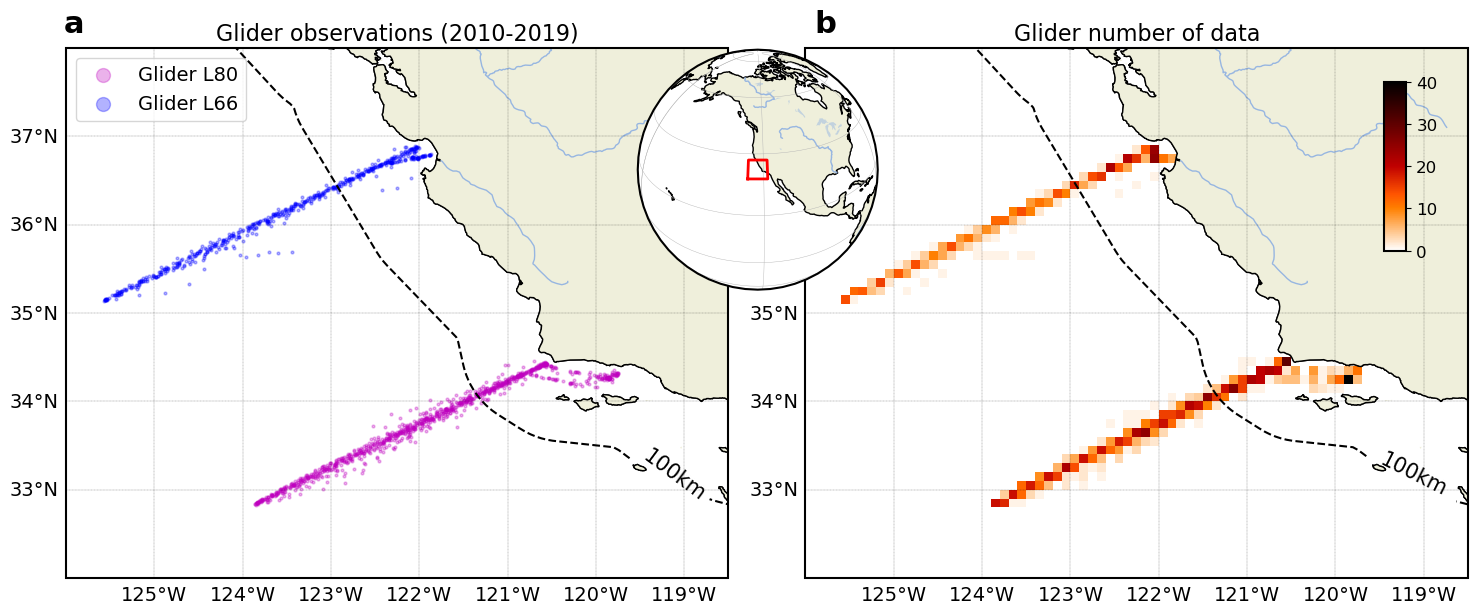

In [63]:
import cartopy.crs as ccrs
import cartopy
import matplotlib.patches as mpatches

zoom = [-126, -118.5, 32, 38.0]
fontsize = 16

fig, axss = set_map(zoom=zoom, figsize=(15*1, 8*1), nrows=1, ncols=2, fsize=14)

axs = axss[1]

pm = plt.pcolormesh(lon, lat, counts, cmap=plt.cm.gist_heat_r, vmax=40)

# =========================================================
# Colorbar repositionnée en haut à droite du 2e plot (inset, plus petite)
# =========================================================
axpos = axs.get_position()
cax_width = 0.015
cax_height = axpos.height * 0.4          # ne couvre que 40% de la hauteur de l'axe
pos_x = axpos.x0 + axpos.width - cax_width - 0.005 + 0.05  # collée au bord droit intérieur
pos_y = axpos.y0 + axpos.height - cax_height - 0.02 + 0.05 # collée en haut

pos_cax = fig.add_axes([pos_x, pos_y, cax_width, cax_height])
cbar = plt.colorbar(pm, cax=pos_cax)
cbar.ax.tick_params(labelsize=fontsize - 4)
#cbar.set_label("Gliders data (2010-2019)", fontsize=fontsize)

axs.set_title("Glider number of data", fontsize=fontsize)
axs.tick_params(axis='both', labelsize=fontsize)

contour = axs.contour(hfr.lon, hfr.lat, dist_grid, [100], zorder=1, linestyles='--', colors='k')
label_positions = [(-119, 33.4)]
axs.clabel(contour, levels=[100], inline=True, manual=label_positions, fontsize=fontsize - 1, fmt='%1.0fkm', colors='k')


filtre = 1

axs = axss[0]

axs.set_title("Glider observations (2010-2019)", fontsize=fontsize)

#axs.plot(glider_L80.lon, glider_L80.lat, transform=ccrs.PlateCarree(), color='m', alpha=0.3, label='Glider L80', linestyle='-', marker='o', markersize=1)
#axs.plot(glider_L66.lon, glider_L66.lat, transform=ccrs.PlateCarree(), color='blue', alpha=0.3, label='Glider L66', linestyle='-', marker='o', markersize=1)

axs.scatter(glider_L80.lon, glider_L80.lat, transform=ccrs.PlateCarree(), color='m', alpha=0.3, label='Glider L80', marker='o', s=4)
axs.scatter(glider_L66.lon, glider_L66.lat, transform=ccrs.PlateCarree(), color='blue', alpha=0.3, label='Glider L66', marker='o', s=4)


contour = axs.contour(hfr.lon, hfr.lat, dist_grid, [100], zorder=1, linestyles='--', colors='k')
label_positions = [(-119, 33.4)]
axs.clabel(contour, levels=[100], inline=True, manual=label_positions, fontsize=fontsize - 1, fmt='%1.0fkm', colors='k')

axs.legend(loc=2, fontsize=fontsize - 2, markerscale=5)
axs.tick_params(axis='both', labelsize=fontsize)

# =========================================================
# GLOBE EN MÉDAILLON : NearsidePerspective, centré au-dessus, entre les 2 plots
# =========================================================
center_lon = 0.5 * (zoom[0] + zoom[1])
center_lat = 0.5 * (zoom[2] + zoom[3])

pos0 = axss[0].get_position()
pos1 = axss[1].get_position()

globe_width = 0.20
globe_height = 0.30
globe_x = 0.5 * (pos0.x1 + pos1.x0) - globe_width / 2
globe_y = max(pos0.y1, pos1.y1) + 0.02 - 0.25

ax_globe = fig.add_axes(
    [globe_x, globe_y, globe_width, globe_height],
    projection=ccrs.NearsidePerspective(central_longitude=center_lon,
                                          central_latitude=center_lat,
                                          satellite_height=10000000)
)

ax_globe.set_global()
ax_globe.add_feature(cartopy.feature.LAND, zorder=2)
ax_globe.add_feature(cartopy.feature.COASTLINE, zorder=2)
ax_globe.add_feature(cartopy.feature.LAKES, alpha=0.5, zorder=2)
ax_globe.add_feature(cartopy.feature.RIVERS, zorder=2)
ax_globe.gridlines(linewidth=0.3, color='0.7')

# Rectangle montrant la zone 'zoom' [lon_min, lon_max, lat_min, lat_max]
rect_lon = [zoom[0], zoom[1], zoom[1], zoom[0], zoom[0]]
rect_lat = [zoom[2], zoom[2], zoom[3], zoom[3], zoom[2]]
ax_globe.plot(rect_lon, rect_lat, color='red', linewidth=2,
              transform=ccrs.PlateCarree(), zorder=5)

fig.text(0.05, 0.88, 'a', fontsize=22, fontweight='bold', ha='left', va='top')
fig.text(0.55, 0.88, 'b', fontsize=22, fontweight='bold', ha='left', va='top')


fig.tight_layout()
plt.savefig("glider_observations.png", dpi=300)
plt.show()